# Kiểm tra dữ liệu Foody / Google Maps

Notebook kiểm tra chất lượng đầu vào cho training, sử dụng **snapshot local được ghi ở cell bên dưới**. Chỉ hiển thị số liệu tổng hợp, không in tên người dùng hoặc bình luận gốc.

## Kết luận cần đọc cùng dữ liệu

Dataset hiện chưa có nhãn người và ngày đăng Maps chính xác. Xem các giá trị được tính lại dưới đây trước khi dùng để huấn luyện hoặc phân tích xu hướng; các biểu đồ mô tả mẫu đã crawl, không đại diện toàn bộ khách hàng.

## Phương pháp và giả định

Grain: một review sau loại ID trùng. Foody thang 10 và Maps thang 5 được vẽ riêng; thành phố/ngày chưa biết giữ thiếu. Kiểm tra SQL read-only; không fit tokenizer, không đổi split. Mục tiêu là xác định dữ liệu còn thiếu để thu thập/gán nhãn.

In [1]:
from pathlib import Path
import json, sqlite3, sys
from contextlib import closing
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/processing/cleaner.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the project or notebooks directory.')
sys.path.insert(0, str(ROOT))
PROCESSED = ROOT / 'data/processed'
if not (PROCESSED / 'latest.json').is_file():
    raise RuntimeError('Run python src/processing/cleaner.py first.')
run_id = json.loads((PROCESSED / 'latest.json').read_text(encoding='utf-8'))['run_id']
assert isinstance(run_id, str) and run_id.isalnum()
SNAPSHOT = PROCESSED / 'runs' / run_id
report = json.loads((SNAPSHOT / 'quality_report.json').read_text(encoding='utf-8'))
manifest = json.loads((SNAPSHOT / 'manifest.json').read_text(encoding='utf-8'))
print('Snapshot:', run_id)
print('Inputs:', [item['path'] for item in manifest['inputs']])


Snapshot: af2c5fbbb7743a69
Inputs: ['foody\\foody_da-nang_dataset.json', 'foody\\foody_ho-chi-minh-city_dataset.json', 'gmap\\gmap_0x316f6d0038ba8d2f_0x84531c4b8fe5b809.json', 'gmap\\gmap_0x316f6d2bbb8b622b_0xb78ce6ab1ecb0ff7.partial.json', 'gmap\\gmap_0x316f6da6ccd13ae7_0xa0a3382a169e5ead.partial.json', 'gmap\\gmap_0x31752615cbb637cd_0x58d42231236126da.json']


## Đọc dữ liệu qua SQLite và kiểm tra tính nhất quán

In [2]:
with closing(sqlite3.connect((SNAPSHOT / 'reviews.sqlite').as_uri() + '?mode=ro', uri=True)) as db:
    assert db.execute('PRAGMA integrity_check').fetchone()[0] == 'ok'
    total = db.execute('SELECT COUNT(*) FROM reviews').fetchone()[0]
    summary = db.execute('SELECT source, COUNT(*), SUM(training_eligible), SUM(city IS NULL), SUM(published_at IS NULL) FROM reviews GROUP BY source ORDER BY source').fetchall()
    ratings = db.execute('SELECT source, rating, rating_scale FROM reviews WHERE rating IS NOT NULL').fetchall()
    split_groups = db.execute('SELECT split_group_id FROM reviews GROUP BY split_group_id HAVING COUNT(DISTINCT split)>1').fetchall()
assert total == report['normalized_rows'] and not split_groups
print('source | review | usable text | missing city | missing publication date')
for row in summary: print(row)
print('Human exports:', {k: report['exports'][k] for k in ['train', 'validation', 'test']})
print('Weak training examples:', report['exports']['weak_train'])


source | review | usable text | missing city | missing publication date
('foody', 24, 24, 0, 0)
('gmap', 185, 167, 155, 185)
Human exports: {'train': 0, 'validation': 0, 'test': 0}
Weak training examples: 89


## Số review đã crawl và số review có thể dùng cho text training

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\TUAN\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


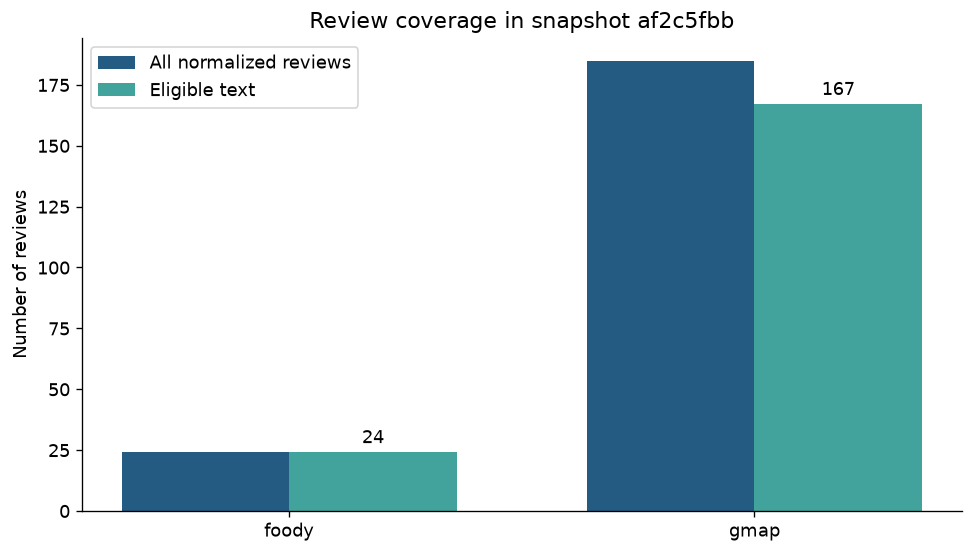

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
x = list(range(len(summary)))
ax.bar([v-.18 for v in x], [r[1] for r in summary], width=.36, label='All normalized reviews', color='#245b83')
bars = ax.bar([v+.18 for v in x], [r[2] for r in summary], width=.36, label='Eligible text', color='#41a39b')
ax.set_xticks(x, [r[0] for r in summary]); ax.set_ylabel('Number of reviews'); ax.set_ylim(bottom=0)
ax.set_title(f'Review coverage in snapshot {run_id[:8]}')
ax.legend(); ax.bar_label(bars, padding=3); plt.show()


Chênh lệch giữa hai cột là mẫu không đủ điều kiện train văn bản (nội dung rỗng/placeholder hoặc trùng dài trong cùng quán). Không đồng nhất số review với số lượt khách.

## Phân bố rating ở thang điểm gốc

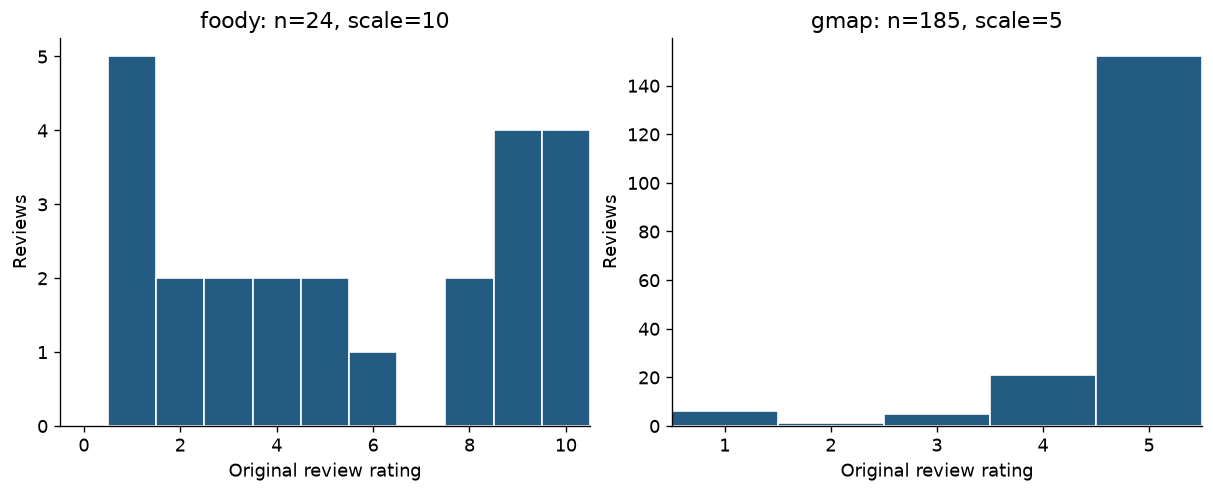

In [4]:
sources = sorted({r[0] for r in ratings})
fig, axes = plt.subplots(1, len(sources), figsize=(10, 4), squeeze=False, layout='constrained')
for ax, source in zip(axes[0], sources):
    values = [r[1] for r in ratings if r[0] == source]
    scale = next(r[2] for r in ratings if r[0] == source)
    bins = [i-.5 for i in range(1, 7)] if source == 'gmap' else [i-.5 for i in range(0, 12)]
    ax.hist(values, bins=bins, color='#245b83', edgecolor='white')
    ax.set(title=f'{source}: n={len(values)}, scale={scale}', xlabel='Original review rating', ylabel='Reviews')
    ax.set_xlim(.5 if source == 'gmap' else -.5, scale+.5); ax.set_ylim(bottom=0)
plt.show()


Trục rating khác nhau theo nguồn. Rating lệch về điểm cao có thể làm nhãn tạm mất cân bằng; đây chưa phải phân bố cảm xúc do người gán.

## Những việc còn phải làm

In [5]:
for message in report['warnings']: print('-', message)
print('Counts by split:', report['by_split'])
print('Restaurants:', report['restaurants'])


- train: human labels missing classes ['negative', 'neutral', 'positive'].
- validation: human labels missing classes ['negative', 'neutral', 'positive'].
- test: human labels missing classes ['negative', 'neutral', 'positive'].
- test: no restaurants from sources ['foody', 'gmap']; collect more independent restaurants.
- Unknown city is kept null; search region was not substituted.
- Relative/unknown dates excluded from monthly time view.
- Weak labels are rating heuristics, not ground truth; do not evaluate on weak labels.
- Near-duplicate grouping is approximate; common short phrases are not merged across restaurants.
- Cross-source restaurant matching is not automatic; restaurant IDs are namespaced by source.
Counts by split: {'validation': 102, 'train': 107}
Restaurants: 8


Giữ nguyên run_id khi so sánh mô hình. Bổ sung quán độc lập, kiểm tra entity quán xuất hiện ở cả hai nguồn, gán nhãn người theo hướng dẫn trong `src/processing/README.md`. Chỉ phân tích xu hướng thời gian sau khi xác minh ngày đăng và độ phủ theo quán/tháng.